# Read the .pts file

In [7]:
from pathlib import Path
import pandas as pd
import numpy as np


scans_dir = Path("/home/fzhcis/mylab/data/inlut3d/setup_0")
scan_path = scans_dir / "setup_0.pts"
scan_path.exists()

from tools.preprocess_point_cloud import read_and_clean_pcd

df = read_and_clean_pcd(scan_path)

Reading a .pts file, for In_LUT3D data.
Read 11527253 points from /home/fzhcis/mylab/data/inlut3d/setup_0/setup_0.pts
---------Before preprocessing:----------
Range of X: -8.219 to 3.302
Range of Y: -0.940 to 2.994
Range of Z: -1.216 to 2.459
Range of r: 0.000 to 255.000
Range of g: 0.000 to 255.000
Range of b: 0.000 to 255.000
Range of class_id: -1.000 to 17.000
Range of instance_id: -1.000 to 9.000
Range of Intensity: 0.001 to 1.000
Range of Return Number: 1.000 to 1.000
Range of azimuth: 0.000 to 359.898
Range of elevation: -62.238 to 90.000
Range of zenith: 0.000 to 152.238
Range of rangemeter: 0.644 to 8.270
!!Intensity normalized to range: 0.0 to 1.0!!
---------After preprocessing:----------
Range of X: -8.219 to 3.302
Range of Y: -0.94 to 2.994
Range of Z: -1.216 to 2.459
Range of r: 0 to 255
Range of g: 0 to 255
Range of b: 0 to 255
Range of class_id: -1 to 17
Range of instance_id: -1 to 9
Range of Intensity: 0.0 to 1.0
Range of Return Number: 1 to 1
Range of azimuth: 0.0 to 35

In [8]:
def read_pts_file(file_path):
    # Read the file
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # First line is the number of points, skip it
    data_lines = lines[1:]

    # Convert to DataFrame
    from io import StringIO
    data_str = ''.join(data_lines)
    df = pd.read_csv(StringIO(data_str), sep='\s+', header=None)
    df.columns = ["X", "Y", "Z", "r", "g", "b", "class_id", "instance_id"]

    return df


In [9]:
df.head()

,X,Y,Z,r,g,b,class_id,instance_id,Intensity,Return Number,azimuth,elevation,zenith,rangemeter
0,0.041,0.011,1.358,232,233,233,0,0,0.912304,1,15.018361,88.209564,1.790436,1.358663
1,0.041,0.011,1.358,224,225,225,0,0,0.880890,1,15.018361,88.209564,1.790436,1.358663
2,0.041,0.011,1.360,232,233,233,0,0,0.912304,1,15.018361,88.212195,1.787805,1.360662
3,0.041,0.011,1.361,228,229,230,0,0,0.897906,1,15.018361,88.213508,1.786492,1.361662
4,0.041,0.011,1.361,224,225,226,0,0,0.882199,1,15.018361,88.213508,1.786492,1.361662


/tmp/ipykernel_255545/57919809.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(unique_values))


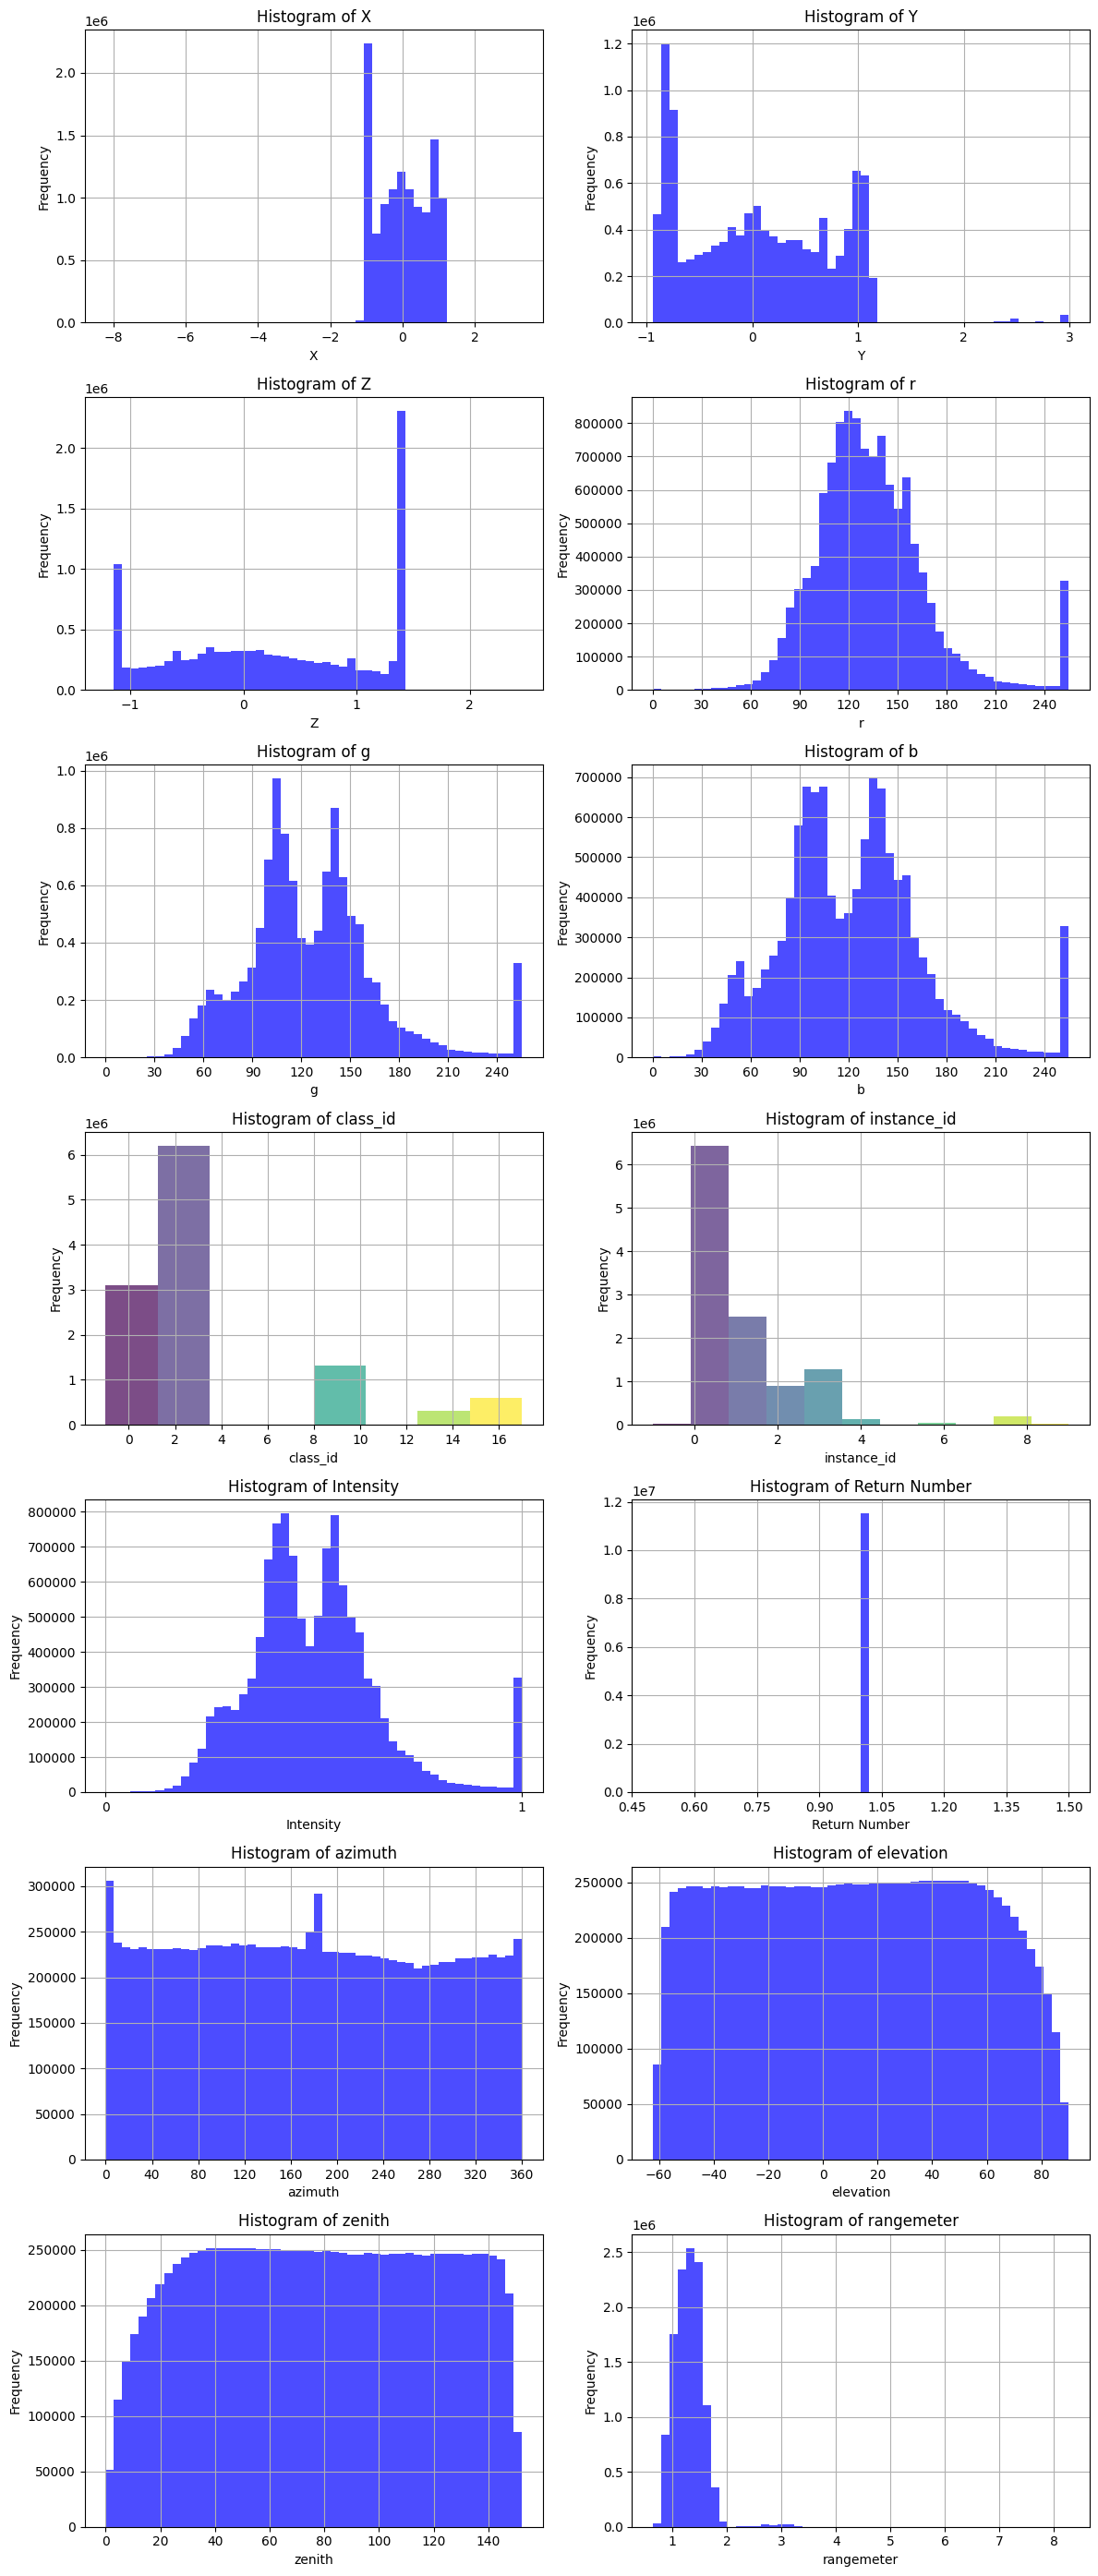

In [10]:
# Plot histograms of each column of the DataFrame, stack them in a [n_columns x 1] grid

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors



def plot_histograms(df):
    columns = df.columns
    n_columns = len(columns)

    n_rows = (n_columns + 1) // 2  # Two columns per row
    fig = plt.figure(figsize=(12, 4 * n_rows))
    gs = gridspec.GridSpec(n_rows, 2, figure=fig)
    for i, column in enumerate(columns):
        ax = fig.add_subplot(gs[i // 2, i % 2])
        if column == "class_id" or column == "instance_id":
            # Use a color map for categorical data
            unique_values = df[column].unique()
            cmap = cm.get_cmap("viridis", len(unique_values))
            norm = mcolors.BoundaryNorm(boundaries=np.arange(len(unique_values) + 1), ncolors=len(unique_values))
            colors = [cmap(norm(i)) for i in range(len(unique_values))]
            hist, bins = np.histogram(df[column], bins=len(unique_values))
            ax.bar(bins[:-1], hist, width=np.diff(bins), align='edge', color=colors, alpha=0.7)
        else:
            ax.hist(df[column], bins=50, alpha=0.7, color='blue')


        ax.set_title(f"Histogram of {column}")
        ax.set_xlabel(column)
        ax.set_ylabel("Frequency")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.grid(True)
    plt.tight_layout()
    plt.show()


plot_histograms(df)

In [11]:
# pt_xyz = [-0.52, -0.378, -1.087]
# pt_xyz = [-0.145, 0.561, -1.091]
pt_xyz = [0.591, 0.218, -1.088]
# calculate the zenith and azimuth angles given the point coordinates
def calculate_angles(pt_xyz):
    x, y, z = pt_xyz
    r = np.sqrt(x**2 + y**2 + z**2)
    zenith = np.arccos(z / r)  # in radians
    azimuth = np.arctan2(y, x)  # in radians
    # Convert to degrees
    zenith = np.degrees(zenith)
    azimuth = np.degrees(azimuth)
    return zenith, azimuth

calculate_angles(pt_xyz)

(149.9302393958741, 20.247319555267758)

(-0.0842584385443048, -3.552713678800501e-15)

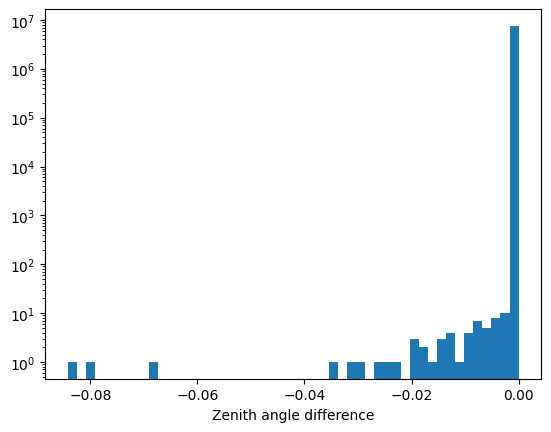

In [23]:
zenith_angles = np.unique(df['zenith'])
zenith_diff = np.unique(zenith_angles[:-1] - zenith_angles[1:])
plt.hist(zenith_diff, bins=50)
plt.yscale("log")
plt.xlabel("Zenith angle difference")
len(zenith_diff)
zenith_diff.min(), zenith_diff.max()
# zenith_diff.mean(), zenith_diff.std()

Text(0, 0.5, 'Count')

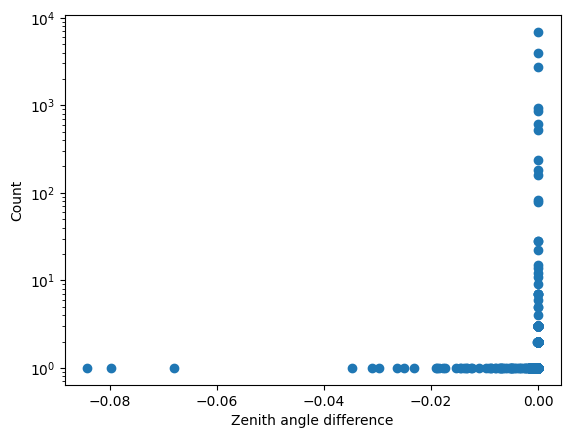

In [ ]:
# import counter
# from counter import Counter

# count the unique values in the zenith_diff array
zenith_diff = zenith_angles[:-1] - zenith_angles[1:]
unique, counts = np.unique(zenith_diff, return_counts=True)


Text(0, 0.5, 'Count')

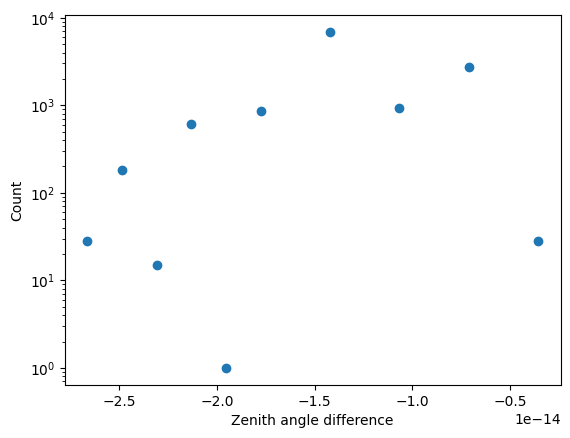

In [27]:
plt.scatter(unique[-10:], counts[-10:])
plt.yscale("log")
plt.xlabel("Zenith angle difference")
plt.ylabel("Count")

In [59]:
18*150/0.063/0.063

680272.1088435374

In [62]:
360*150/0.066/0.066

12396694.214876032